# standard codes

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import time
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
from IPython.display import clear_output
from scipy import stats
from scipy.stats import t

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [3]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [4]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

#new codes

In [5]:
drive_path = '/content/drive/MyDrive/docs'
os.makedirs(drive_path, exist_ok=True)

In [7]:
files = np.sort(glob.glob(f"{drive_path}/sub*.json"))
logs = []
max_lines = 15

def log_message(message):
    logs.append(message)
    if len(logs) > max_lines:
        logs.pop(0) # Remove the oldest message
    clear_output(wait=True)
    for msg in logs:
        print(msg)

for i in range(snapshot['num_groups_subfind']):
    if i % int(snapshot['num_groups_subfind']/1000) == 0:
        log_message(str(i))

    if f"{drive_path}/sub{i}.json" in files:
        log_message(f"skipping i: {i}") # Log skipping
        continue # Skip the download part if file exists

    sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/{i}/"
    subhalo = get((sub_url), out_filename=f"{drive_path}/sub{i}.json")

    if i > 6:
        break

skipping i: 10168
skipping i: 10169
skipping i: 10170
skipping i: 10171
skipping i: 10172
skipping i: 10173
skipping i: 10174
skipping i: 10175
skipping i: 10176
skipping i: 10177
skipping i: 10178
skipping i: 10179
skipping i: 10180
skipping i: 10181
skipping i: 10182


KeyboardInterrupt: 

In [8]:
amount = 10000
bhmdot = np.zeros(amount) -1
sfr = np.zeros(amount) -1

print('bhmdot: ', bhmdot)
print("sfr: ", sfr)

save_file = f"{drive_path}/bh_sfr.npz"
if os.path.exists(save_file):
    data = np.load(save_file)
    bhmdot[:amount] = data['bhmdot'][:amount]
    sfr[:amount] = data['sfr'][:amount]

print('bhmdot: ', bhmdot)
print("sfr: ", sfr)

for i in range(amount):
    if bhmdot[i] >= 0:
        continue
    if sfr[i] >= 0:
        continue
    with open(files[i], 'r') as fid:
        data = json.load(fid)
    bhmdot[i] = data['bhmdot']
    sfr[i] = data['sfr']
    if i > amount:
        break
    np.savez_compressed(save_file, bhmdot=bhmdot, sfr=sfr)

bhmdot:  [-1. -1. -1. ... -1. -1. -1.]
sfr:  [-1. -1. -1. ... -1. -1. -1.]
bhmdot:  [ 3.51652e-03  1.66792e-02  5.11530e-04 ... -1.00000e+00 -1.00000e+00
 -1.00000e+00]
sfr:  [410.991    61.4731    1.57871 ...  -1.       -1.       -1.     ]


KeyboardInterrupt: 

In [9]:
bhl = bhmdot[(bhmdot != -1) & (bhmdot != 0)].tolist()
sfrl = sfr[(sfr != -1) & (sfr != 0)].tolist()

bins = np.logspace(-4, 3, 10)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

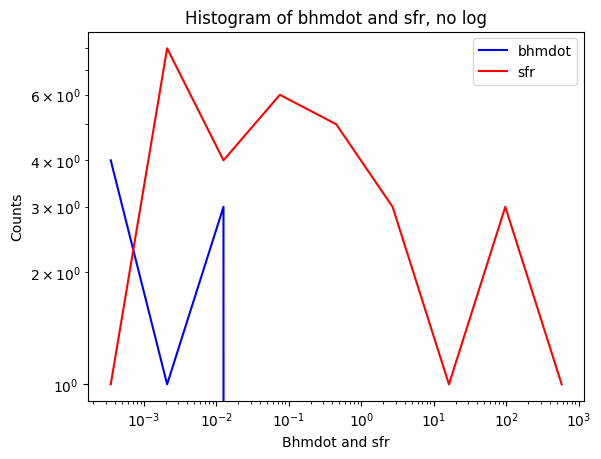

In [10]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr, no log')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()

In [12]:
bh_median = np.median(bhl)
sfr_median = np.median(sfrl)

bh_mean = np.mean(bhl)
sfr_mean = np.mean(sfrl)

bh_std = np.std(bhl)
sfr_std = np.std(sfrl)

counts3, _ = np.histogram(bh_median, bins=bins)
counts4, _ = np.histogram(sfr_median, bins=bins)
counts5, _ = np.histogram(bh_mean, bins=bins)
counts6, _ = np.histogram(sfr_mean, bins=bins)

/tmp/ipython-input-6929/1172040491.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])


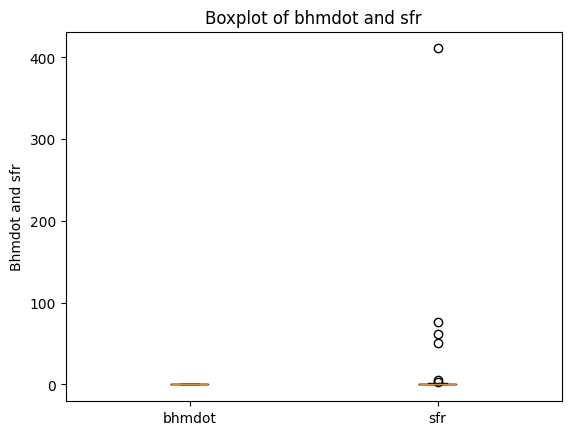

In [13]:
plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])
plt.title('Boxplot of bhmdot and sfr')
plt.ylabel('Bhmdot and sfr')
plt.show()

/tmp/ipython-input-6929/4140522431.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])


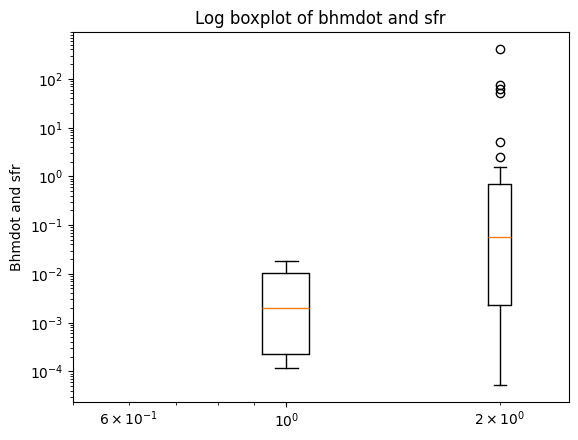

In [14]:
plt.boxplot([bhl, sfrl], labels=['bhmdot', 'sfr'])
plt.title('Log boxplot of bhmdot and sfr')
plt.ylabel('Bhmdot and sfr')
plt.yscale('log')
plt.xscale('log')
plt.show()

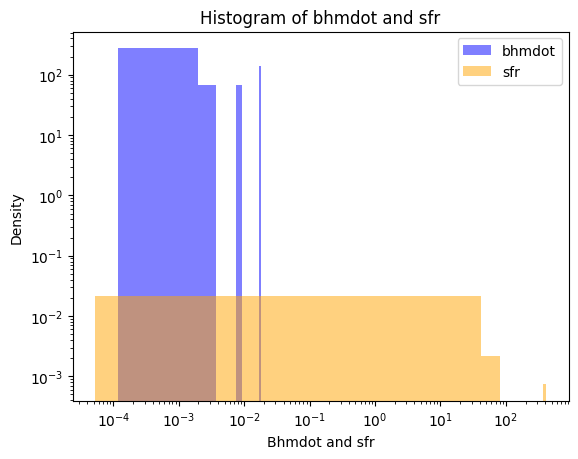

In [15]:
plt.hist(bhl, bins=10, alpha=0.5, label='bhmdot', color='blue', density=True)
plt.hist(sfrl, bins=10, alpha=0.5, label='sfr', color='orange', density=True)
plt.title('Histogram of bhmdot and sfr')
plt.xlabel('Bhmdot and sfr')
plt.ylabel('Density')
plt.yscale('log')
plt.xscale('log')
plt.legend()

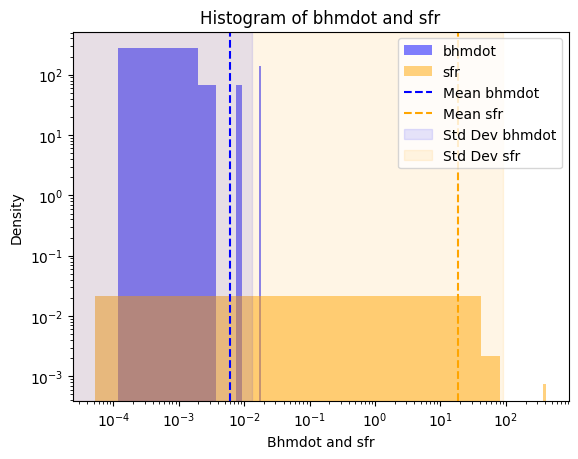

In [16]:
plt.hist(bhl, bins=10, alpha=0.5, label='bhmdot', color='blue', density=True)
plt.hist(sfrl, bins=10, alpha=0.5, label='sfr', color='orange', density=True)

plt.axvline(bh_mean, color='blue', linestyle='--', label='Mean bhmdot')
plt.axvline(sfr_mean, color='orange', linestyle='--', label='Mean sfr')

plt.axvspan(bh_mean - bh_std, bh_mean + bh_std, alpha=0.1, color='blue', label='Std Dev bhmdot')
plt.axvspan(sfr_mean - sfr_std, sfr_mean + sfr_std, alpha=0.1, color='orange', label='Std Dev sfr')


plt.title('Histogram of bhmdot and sfr')
plt.xlabel('Bhmdot and sfr')
plt.ylabel('Density')

plt.yscale('log')
plt.xscale('log')
plt.legend()

In [18]:
t_stat, p_val = stats.ttest_ind(bhmdot, sfr)

print(f"t_stat: {t_stat: .2f}")
print(f"p-val: {p_val: .3f}")

alpha = 0.05
if p_val < alpha:
    print(f"Since p-value ({p_val: .3f} is < than alpha ({alpha})), we reject the null hypothesis")
elif p_val > alpha:
    print(f"Since p-value ({p_val: .3f} is > than alpha ({alpha})), we accept the null hypothesis")

t_stat: -1.42
p-val:  0.155
Since p-value ( 0.155 is > than alpha (0.05)), we accept the null hypothesis


In [19]:
np.corrcoef(bhmdot, sfr)

array([[1.        , 0.12105916],
       [0.12105916, 1.        ]])